In [5]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn import set_config
from tempfile import TemporaryDirectory
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import warnings

c:\Users\abhin\.pyenv\pyenv-win\versions\3.14.2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
target_column = "health_condition"

In [7]:
X_train = pd.read_csv("../data/intermediate/train_features_oheencoded_imputed.csv")
X_valid = pd.read_csv("../data/intermediate/valid_features_oheencoded_imputed.csv")
X_test = pd.read_csv("../data/intermediate/test_features_oheencoded_imputed.csv")

y_train = pd.read_csv("../data/intermediate/train_labels.csv")
y_valid = pd.read_csv("../data/intermediate/valid_labels.csv")

X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 552070 entries, 0 to 552069
Data columns (total 39 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   sleep_duration                     552070 non-null  float64
 1   heart_rate                         552070 non-null  float64
 2   bmi                                552070 non-null  float64
 3   calorie_expenditure                552070 non-null  float64
 4   step_count                         552070 non-null  float64
 5   exercise_duration                  552070 non-null  float64
 6   water_intake                       552070 non-null  float64
 7   stress_level                       552070 non-null  float64
 8   sleep_quality                      552070 non-null  float64
 9   physical_activity_level            552070 non-null  float64
 10  smoking_alcohol                    552070 non-null  float64
 11  calorie_expenditure_per_step       552070 non-null

In [8]:
X = pd.concat([X_train, X_valid], axis=0)
y = pd.concat([y_train, y_valid], axis=0)

In [9]:
df_submission = pd.read_csv("../data/sample_submission.csv")
df_submission.info()

<class 'pandas.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   id                295753 non-null  int64
 1   health_condition  295753 non-null  str  
dtypes: int64(1), str(1)
memory usage: 4.5 MB


In [10]:
train_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
valid_sample_weight = compute_sample_weight(class_weight="balanced", y=y_valid)
y_sample_weight = compute_sample_weight(class_weight="balanced", y=y)

model_base = AdaBoostClassifier(n_estimators=100, learning_rate=1.0)
model_base.fit(X_train, y_train, sample_weight=train_sample_weight)

joblib.dump(model_base, '../models/adaboost_80.pkl')

c:\Users\abhin\.pyenv\pyenv-win\versions\3.14.2\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


['../models/adaboost_80.pkl']

In [16]:
from sklearn.metrics import balanced_accuracy_score

y_valid_pred = model_base.predict(X_valid)

val_score = balanced_accuracy_score(y_valid, y_valid_pred, sample_weight=valid_sample_weight)
print("Validation Balanced Accuracy:", val_score)

Validation Balanced Accuracy: 0.9007373204183504


In [12]:
model = AdaBoostClassifier(n_estimators=100, learning_rate=1.0)
model.fit(X, y, sample_weight=y_sample_weight)

joblib.dump(model, '../models/adaboost_100.pkl')

c:\Users\abhin\.pyenv\pyenv-win\versions\3.14.2\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


['../models/adaboost_100.pkl']

In [13]:
y_pred = model.predict(X_test)

df_submission[target_column] = y_pred
df_submission[target_column] = df_submission[target_column].replace({0:'unhealthy', 1:'at-risk', 2: 'fit'})

df_submission.to_csv('../results/adaboost_baseline.csv', index=False)
df_submission

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,fit
295749,985837,at-risk
295750,985838,unhealthy
295751,985839,at-risk


In [17]:
print(classification_report(y_valid, y_valid_pred, target_names=['unhealthy', 'at-risk', 'fit']))

              precision    recall  f1-score   support

   unhealthy       0.50      0.95      0.65     11438
     at-risk       0.99      0.81      0.89    118621
         fit       0.38      0.95      0.54      7959

    accuracy                           0.83    138018
   macro avg       0.62      0.90      0.69    138018
weighted avg       0.91      0.83      0.85    138018



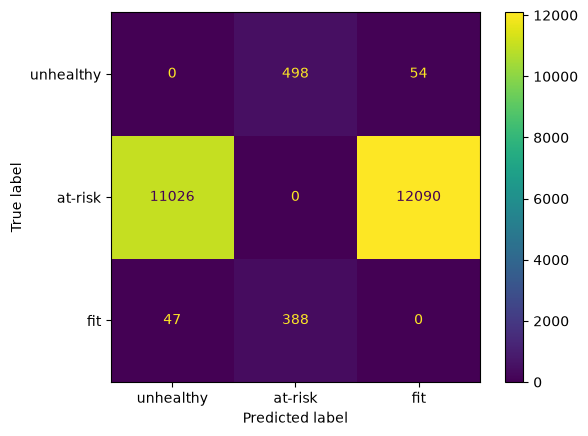

In [18]:
cm = confusion_matrix(y_valid, y_valid_pred, labels=model_base.classes_)
off_diag_cm = cm*(1-np.identity(3).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=off_diag_cm, display_labels=['unhealthy', 'at-risk', 'fit'])
disp.plot(values_format='')
plt.show()